# Wolf Sheep Predation

In the Mesa Wolf–Sheep agent-based model, wolves and sheep interact within a spatial environment. Sheep move across the landscape and consume grass for energy, while wolves move in search of sheep and gain energy through successful predation. Wolves and sheep lose energy as they move and may reproduce when they have sufficient resources, while individuals die when their energy is depleted. These individual-level behaviours and predator–prey interactions collectively generate population-level dynamics over time.

In [1]:
import itertools
import matplotlib.pyplot as plt

wolf_reproduce = [3, 5, 10, 15]
wolf_gain_from_food = [10, 15, 30, 40]

grid = list(
    itertools.product(
        wolf_reproduce,
        wolf_gain_from_food,
    )
)

x, y = zip(*grid)

plt.figure(figsize=(7, 5))

plt.scatter(x, y, s=80)

plt.xlabel("Wolf Reproduction")
plt.ylabel("Wolf Gain From Food")
plt.title("Parameter Sweep")

plt.xticks(wolf_reproduce)
plt.yticks(wolf_gain_from_food)

plt.tight_layout()
plt.show()

<Figure size 700x500 with 1 Axes>

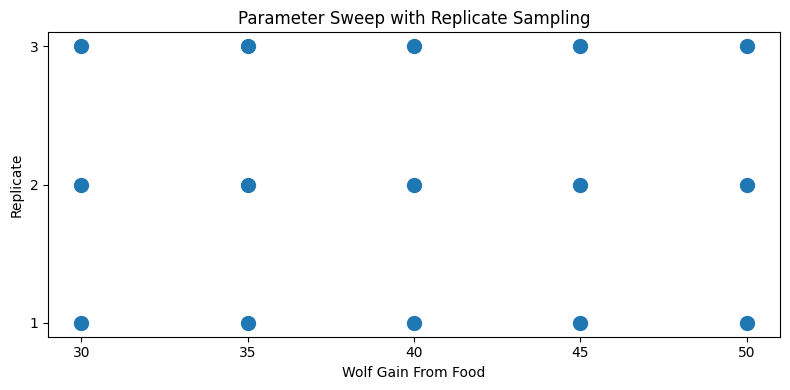

In [2]:
import numpy as np
import matplotlib.pyplot as plt

wolf_gain = np.arange(30, 51, 5)
replicates = [1, 2, 3]

x = np.repeat(wolf_gain, len(replicates))
y = np.tile(replicates, len(wolf_gain))

plt.figure(figsize=(8, 4))

plt.scatter(x, y, s=100)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Replicate")

plt.xticks(wolf_gain)
plt.yticks(replicates)

plt.title("Parameter Sweep with Replicate Sampling")

plt.tight_layout()
plt.show()

                            ST   ST_conf
sheep_reproduce       0.317360  0.262379
wolf_reproduce        0.019195  0.012111
wolf_gain_from_food   0.697411  0.458728
grass_regrowth_time   0.063936  0.065653
sheep_gain_from_food  0.226161  0.205635
                            S1   S1_conf
sheep_reproduce       0.102277  0.148235
wolf_reproduce       -0.023731  0.064636
wolf_gain_from_food   0.429226  0.253708
grass_regrowth_time  -0.025686  0.076362
sheep_gain_from_food -0.071081  0.167893
              Parameter        S1        ST
2   wolf_gain_from_food  0.429226  0.697411
0       sheep_reproduce  0.102277  0.317360
4  sheep_gain_from_food -0.071081  0.226161
3   grass_regrowth_time -0.025686  0.063936
1        wolf_reproduce -0.023731  0.019195


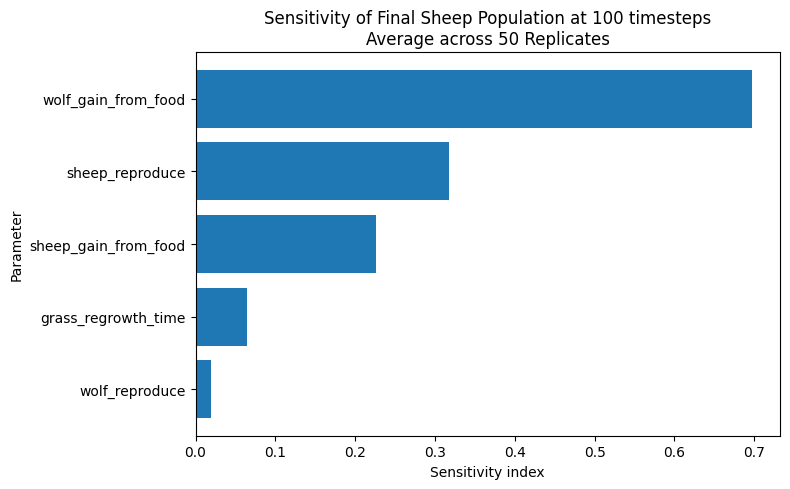

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from SALib import ProblemSpec
from caliagent.models import WolfSheep


N_STEPS = 100
N_REPLICATES = 50


def evaluate(params):
    """Mean final sheep population across replicate simulations."""

    (
        sheep_reproduce,
        wolf_reproduce,
        wolf_gain_from_food,
        grass_regrowth_time,
        sheep_gain_from_food,
    ) = params

    final_sheep = np.empty(N_REPLICATES)

    for replicate in range(N_REPLICATES):
        model = WolfSheep(
            grass=True,
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=int(round(grass_regrowth_time)),
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        for _ in range(N_STEPS):
            model.step()

        # Sheep population at the end of this simulation
        final_sheep[replicate] = model.sheep_count

    # Average final population across the 50 replicates
    return final_sheep.mean()


problem = {
    "names": [
        "sheep_reproduce",
        "wolf_reproduce",
        "wolf_gain_from_food",
        "grass_regrowth_time",
        "sheep_gain_from_food",
    ],
    "bounds": [
        [0.01, 0.10],
        [0.01, 0.10],
        [5, 40],
        [10, 50],
        [1, 10],
    ],
}


sp = ProblemSpec(problem)

sp.sample_sobol(
    128,
    calc_second_order=False,
)

Y = np.array([
    evaluate(params)
    for params in sp.samples
])

sp.set_results(Y)

sp.analyze_sobol(
    calc_second_order=False,
    print_to_console=True,
)

sensitivity = (
    pd.DataFrame({
        "Parameter": problem["names"],
        "S1": sp.analysis["S1"],
        "ST": sp.analysis["ST"],
    })
    .sort_values("ST", ascending=False)
)

print(sensitivity)

plt.figure(figsize=(8, 5))

plt.barh(
    sensitivity["Parameter"],
    sensitivity["ST"],
)

plt.xlabel("Sensitivity index")
plt.ylabel("Parameter")
plt.title(
    "Sensitivity of Final Sheep Population at 100 timesteps\n"
    "Average across 50 Replicates"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

[I 2026-08-31 22:14:55,590] A new study created in memory with name: no-name-94efc9af-80ab-44c2-8685-8e853465b80d
[I 2026-08-31 22:14:56,404] Trial 7 finished with value: 14400.0 and parameters: {'sheep_reproduce': 0.063459221807242, 'wolf_reproduce': 0.06368829164547866, 'wolf_gain_from_food': 36.45737253603784, 'grass_regrowth_time': 12, 'sheep_gain_from_food': 6.566771572259324}. Best is trial 7 with value: 14400.0.
[I 2026-08-31 22:14:56,415] Trial 1 finished with value: 5052.3664 and parameters: {'sheep_reproduce': 0.07769497663191434, 'wolf_reproduce': 0.0911235251547878, 'wolf_gain_from_food': 10.160865872282159, 'grass_regrowth_time': 24, 'sheep_gain_from_food': 5.875518030185673}. Best is trial 1 with value: 5052.3664.
[I 2026-08-31 22:14:56,439] Trial 2 finished with value: 14400.0 and parameters: {'sheep_reproduce': 0.04826121105989003, 'wolf_reproduce': 0.03176279038808111, 'wolf_gain_from_food': 17.42139445703011, 'grass_regrowth_time': 40, 'sheep_gain_from_food': 1.283404

Target sheep: 120
Best error: 3.6864000000000066

Best parameters:
  sheep_reproduce: 0.047540129128114346
  wolf_reproduce: 0.09583593040874747
  wolf_gain_from_food: 6.598009734071345
  grass_regrowth_time: 24
  sheep_gain_from_food: 9.347855003070398

Mean final sheep: 97.08
Standard deviation: 56.62184737360659


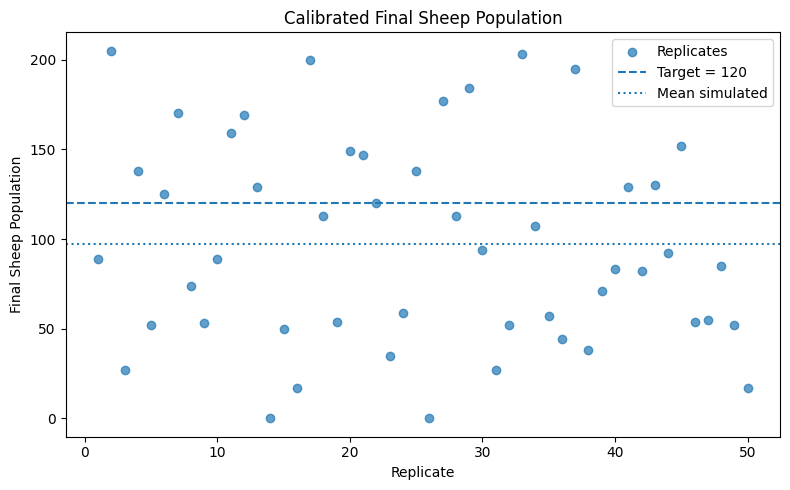

,number,value,datetime_start,datetime_complete,duration,params_grass_regrowth_time,params_sheep_gain_from_food,params_sheep_reproduce,params_wolf_gain_from_food,params_wolf_reproduce,state
0,0,14400.0000,2026-08-31 22:14:55.593263,2026-08-31 22:14:56.518607,0 days 00:00:00.925344,47,9.715757,0.021609,30.947152,0.055246,COMPLETE
1,1,5052.3664,2026-08-31 22:14:55.600275,2026-08-31 22:14:56.415301,0 days 00:00:00.815026,24,5.875518,0.077695,10.160866,0.091124,COMPLETE
2,2,14400.0000,2026-08-31 22:14:55.602509,2026-08-31 22:14:56.439858,0 days 00:00:00.837349,40,1.283405,0.048261,17.421394,0.031763,COMPLETE
3,3,14108.6884,2026-08-31 22:14:55.604372,2026-08-31 22:14:56.449566,0 days 00:00:00.845194,37,6.258283,0.032763,17.490905,0.074695,COMPLETE
4,4,14285.0304,2026-08-31 22:14:55.605558,2026-08-31 22:14:56.487467,0 days 00:00:00.881909,42,5.637864,0.057651,16.669489,0.038235,COMPLETE


In [4]:
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt

from caliagent.models import WolfSheep


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

N_STEPS = 100
N_REPLICATES = 50

TARGET_SHEEP = 120

INITIAL_SHEEP = 100
INITIAL_WOLVES = 50


# ------------------------------------------------------------
# Run replicate simulations
# ------------------------------------------------------------

def simulate_replicates(
    sheep_reproduce,
    wolf_reproduce,
    wolf_gain_from_food,
    grass_regrowth_time,
    sheep_gain_from_food,
):
    """Return final sheep counts across replicate simulations."""

    final_sheep = np.empty(N_REPLICATES)

    for replicate in range(N_REPLICATES):
        model = WolfSheep(
            initial_sheep=INITIAL_SHEEP,
            initial_wolves=INITIAL_WOLVES,
            grass=True,
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=grass_regrowth_time,
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        for _ in range(N_STEPS):
            model.step()

        final_sheep[replicate] = model.sheep_count

    return final_sheep


# ------------------------------------------------------------
# Optuna objective
# ------------------------------------------------------------

def objective(trial):
    sheep_reproduce = trial.suggest_float(
        "sheep_reproduce",
        0.01,
        0.10,
    )

    wolf_reproduce = trial.suggest_float(
        "wolf_reproduce",
        0.01,
        0.10,
    )

    wolf_gain_from_food = trial.suggest_float(
        "wolf_gain_from_food",
        5.0,
        40.0,
    )

    grass_regrowth_time = trial.suggest_int(
        "grass_regrowth_time",
        10,
        50,
    )

    sheep_gain_from_food = trial.suggest_float(
        "sheep_gain_from_food",
        1.0,
        10.0,
    )

    final_sheep = simulate_replicates(
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=wolf_reproduce,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=grass_regrowth_time,
        sheep_gain_from_food=sheep_gain_from_food,
    )

    mean_final_sheep = final_sheep.mean()

    error = (
        mean_final_sheep - TARGET_SHEEP
    ) ** 2

    return error


# ------------------------------------------------------------
# Optimisation
# ------------------------------------------------------------

study = optuna.create_study(
    direction="minimize",
)

study.optimize(
    objective,
    n_trials=100,
    n_jobs=8,
)


# ------------------------------------------------------------
# Best result
# ------------------------------------------------------------

print("Target sheep:", TARGET_SHEEP)
print("Best error:", study.best_value)

print("\nBest parameters:")

for parameter, value in study.best_params.items():
    print(f"  {parameter}: {value}")


# ------------------------------------------------------------
# Evaluate calibrated parameters
# ------------------------------------------------------------

best_final_sheep = simulate_replicates(
    **study.best_params,
)

print(
    "\nMean final sheep:",
    best_final_sheep.mean(),
)

print(
    "Standard deviation:",
    best_final_sheep.std(),
)


# ------------------------------------------------------------
# Plot replicate outcomes
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    np.arange(1, N_REPLICATES + 1),
    best_final_sheep,
    alpha=0.7,
    label="Replicates",
)

plt.axhline(
    TARGET_SHEEP,
    linestyle="--",
    label="Target = 120",
)

plt.axhline(
    best_final_sheep.mean(),
    linestyle=":",
    label="Mean simulated",
)

plt.xlabel("Replicate")
plt.ylabel("Final Sheep Population")
plt.title("Calibrated Final Sheep Population")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Optuna trials
# ------------------------------------------------------------

trials = study.trials_dataframe()

trials.head()

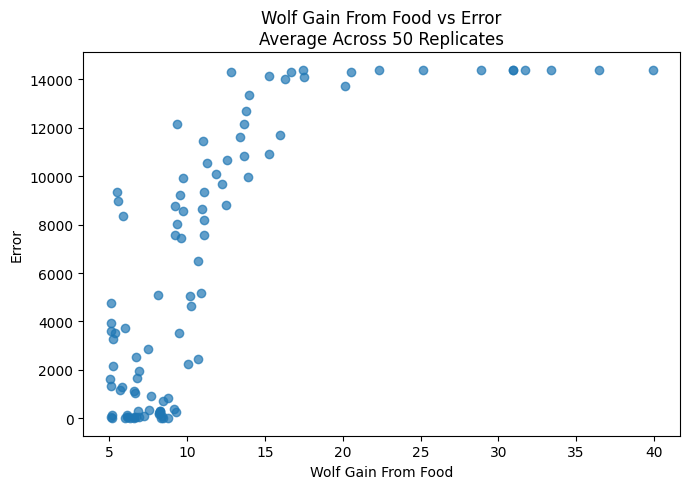

In [5]:
trials = study.trials_dataframe().sort_values("value")

import matplotlib.pyplot as plt

param_cols = [
    "params_wolf_gain_from_food",

]

for param in param_cols:
    plt.figure(figsize=(7, 5))

    plt.scatter(
        trials[param],
        trials["value"],
        alpha=0.7,
    )

    plt.xlabel(
        param.replace("params_", "").replace("_", " ").title()
    )
    plt.ylabel("Error")
    plt.title("Wolf Gain From Food vs Error\n""Average Across 50 Replicates")

    plt.tight_layout()
    plt.show()

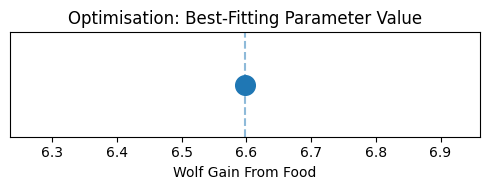

In [6]:
best_trial = trials.loc[trials["value"].idxmin()]

best_value = best_trial["params_wolf_gain_from_food"]

plt.figure(figsize=(5, 2))

plt.scatter(
    best_value,
    0,
    s=200,
)

plt.axvline(
    best_value,
    linestyle="--",
    alpha=0.5,
)

plt.xlabel("Wolf Gain From Food")
plt.yticks([])
plt.title("Optimisation: Best-Fitting Parameter Value")

plt.tight_layout()
plt.show()

ABC.Sampler INFO: Parallelize sampling on 16 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-08-31 22:15:22>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 8.60000000e+01.
ABC INFO: Accepted: 200 / 440 = 4.5455e-01, ESS: 2.0000e+02.
ABC INFO: Timing t=0 [s]: total=1.46, simulation=1 (69%), pipeline-setup=0.00385, prepare-next=0.136 (population-size=0.00457, distance=0.000374).
ABC INFO: t: 1, eps: 4.80000000e+01.
ABC INFO: Accepted: 200 / 507 = 3.9448e-01, ESS: 1.3227e+02.
ABC INFO: Timing t=1 [s]: total=1.35, simulation=1.18 (87%), pipeline-setup=0.00148, prepare-next=0.0173 (population-size=0.00314, distance=0.000316).
ABC INFO: t: 2, eps: 2.70000000e+01.
ABC INFO: Accepted: 200 / 659 = 3.0349e-01, ESS: 1.1854e+02.
ABC INFO: Timing t=2 [s]: total=0.873, simulation=0.73 (84%), pipeline-setup=0.00128, prepare-next=0.0136 (population-size=0.00299, distance=0.000384).
ABC INFO: t: 3, eps: 1.50000000e+01.
ABC INFO: Accepted: 200 / 901 = 2.2198e-01, ESS: 8.8210e

name  grass_regrowth_time  sheep_gain_from_food  sheep_reproduce  \
id                                                                 
1002            28.330180              7.096682         0.076002   
1003            29.362642              6.925998         0.058961   
1004            39.972282              8.779351         0.072685   
1005            21.179314              5.852607         0.046853   
1006            23.588105              7.245480         0.037120   

name  wolf_gain_from_food  wolf_reproduce    weight  
id                                                   
1002             6.548254        0.058467  0.003477  
1003             6.959317        0.074670  0.002773  
1004             6.498423        0.080115  0.005958  
1005             4.517164        0.024656  0.003671  
1006             5.605753        0.090827  0.003198  

Posterior means:
sheep_reproduce: 0.070
wolf_reproduce: 0.059
wolf_gain_from_food: 6.355
grass_regrowth_time: 24.564
sheep_gain_from_food: 6.879

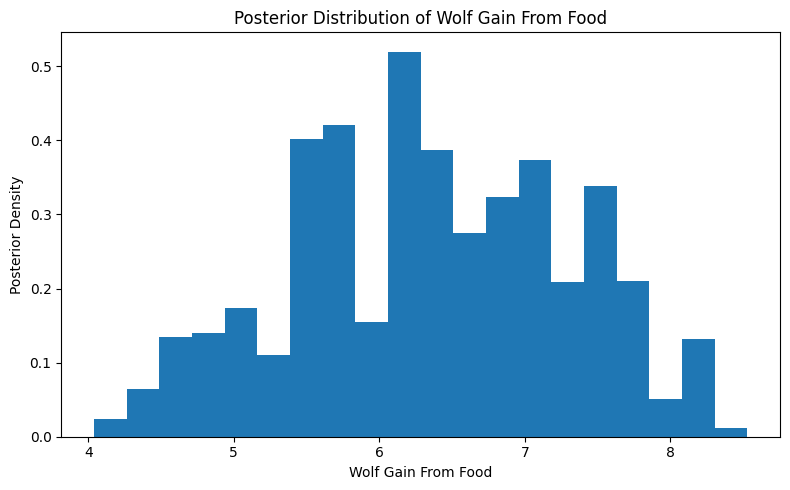

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyabc

from caliagent.models import WolfSheep


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

N_STEPS = 100

TARGET_SHEEP = 120

INITIAL_SHEEP = 100
INITIAL_WOLVES = 50


# ------------------------------------------------------------
# pyABC model
# ------------------------------------------------------------

def model(parameters):
    """Run one stochastic Wolf-Sheep simulation."""

    model = WolfSheep(
        initial_sheep=INITIAL_SHEEP,
        initial_wolves=INITIAL_WOLVES,
        grass=True,
        sheep_reproduce=parameters["sheep_reproduce"],
        wolf_reproduce=parameters["wolf_reproduce"],
        wolf_gain_from_food=parameters["wolf_gain_from_food"],
        grass_regrowth_time=int(
            round(parameters["grass_regrowth_time"])
        ),
        sheep_gain_from_food=parameters["sheep_gain_from_food"],
    )

    for _ in range(N_STEPS):
        model.step()

    return {
        "final_sheep": model.sheep_count,
    }


# ------------------------------------------------------------
# Prior distributions
# ------------------------------------------------------------

prior = pyabc.Distribution(
    sheep_reproduce=pyabc.RV(
        "uniform",
        0.01,
        0.09,
    ),
    wolf_reproduce=pyabc.RV(
        "uniform",
        0.01,
        0.09,
    ),
    wolf_gain_from_food=pyabc.RV(
        "norm",
        6.5,
        1.0,
    ),
    grass_regrowth_time=pyabc.RV(
        "uniform",
        10.0,
        40.0,
    ),
    sheep_gain_from_food=pyabc.RV(
        "uniform",
        1.0,
        9.0,
    ),
)


# ------------------------------------------------------------
# Observed data
# ------------------------------------------------------------

observed = {
    "final_sheep": TARGET_SHEEP,
}


# ------------------------------------------------------------
# Distance function
# ------------------------------------------------------------

def distance(simulated, observed):
    """Absolute difference from target sheep population."""

    return abs(
        simulated["final_sheep"]
        - observed["final_sheep"]
    )


# ------------------------------------------------------------
# ABC-SMC
# ------------------------------------------------------------

abc = pyabc.ABCSMC(
    model,
    prior,
    distance,
    population_size=200
)

abc.new(
    "sqlite://",
    observed,
)

history = abc.run(
    minimum_epsilon=5.0,
    # max_nr_populations=1000,
    # max_total_nr_simulations=1000, 
    # min_acceptance_rate=0.0
)


# ------------------------------------------------------------
# Posterior samples
# ------------------------------------------------------------

posterior, weights = history.get_distribution(
    m=0,
    t=history.max_t,
)

posterior["weight"] = weights

print(posterior.head())


# ------------------------------------------------------------
# Posterior summaries
# ------------------------------------------------------------

parameters = [
    "sheep_reproduce",
    "wolf_reproduce",
    "wolf_gain_from_food",
    "grass_regrowth_time",
    "sheep_gain_from_food",
]

print("\nPosterior means:")

for parameter in parameters:
    posterior_mean = np.average(
        posterior[parameter],
        weights=posterior["weight"],
    )

    print(
        f"{parameter}: {posterior_mean:.3f}"
    )


# ------------------------------------------------------------
# Plot posterior for wolf gain from food
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    posterior["wolf_gain_from_food"],
    weights=posterior["weight"],
    bins=20,
    density=True,
)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Posterior Density")
plt.title(
    "Posterior Distribution of Wolf Gain From Food"
)

plt.tight_layout()
plt.show()

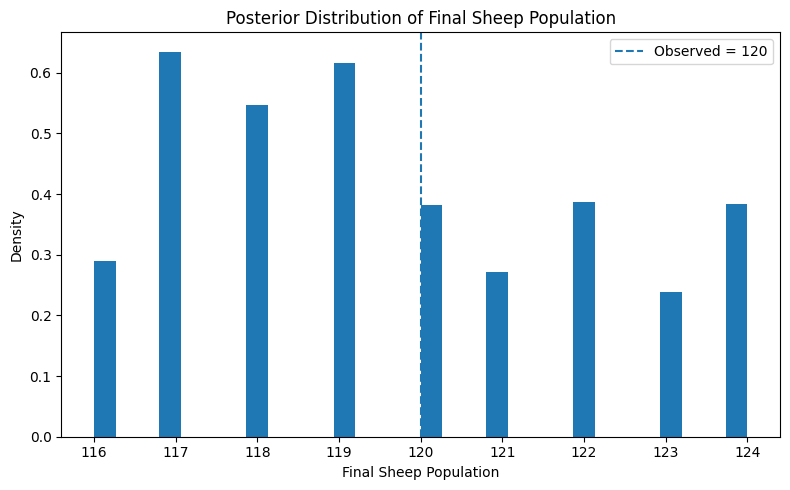

In [8]:
weights, sum_stats = history.get_weighted_sum_stats_for_model(
    m=0,
    t=history.max_t,
)

final_sheep = np.array([
    stat["final_sheep"]
    for stat in sum_stats
])

plt.figure(figsize=(8, 5))

plt.hist(
    final_sheep,
    weights=weights,
    bins=30,
    density=True,
)

plt.axvline(
    TARGET_SHEEP,
    linestyle="--",
    label="Observed = 120",
)

plt.xlabel("Final Sheep Population")
plt.ylabel("Density")
plt.title("Posterior Distribution of Final Sheep Population")
plt.legend()

plt.tight_layout()
plt.show()

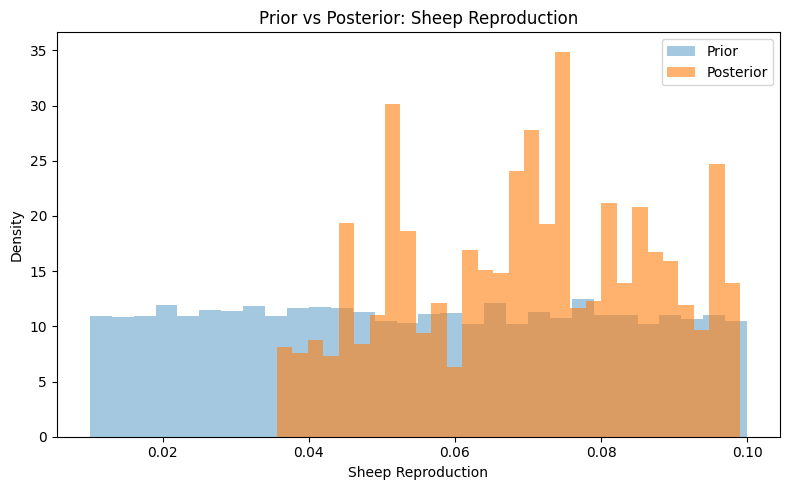

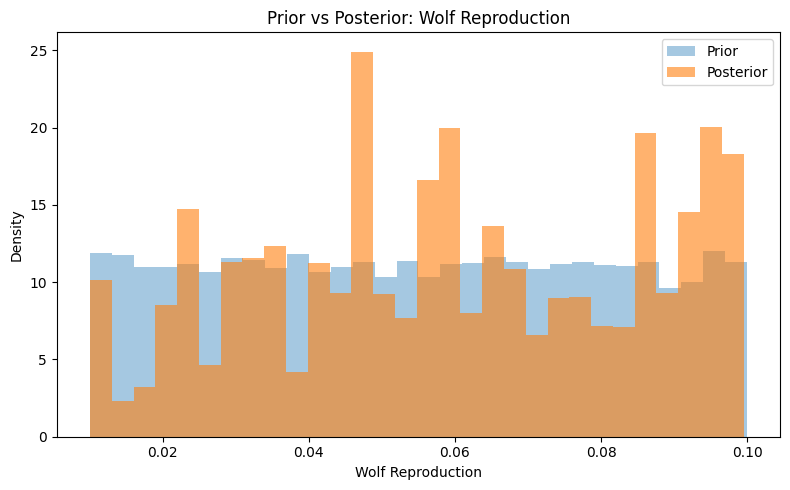

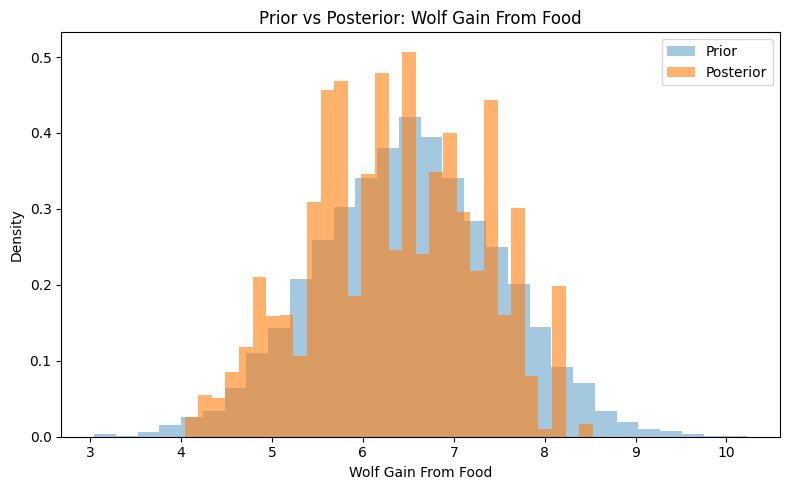

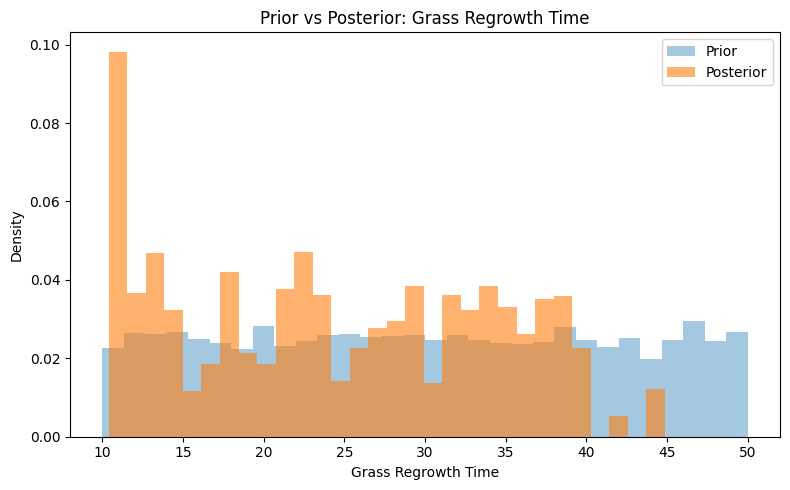

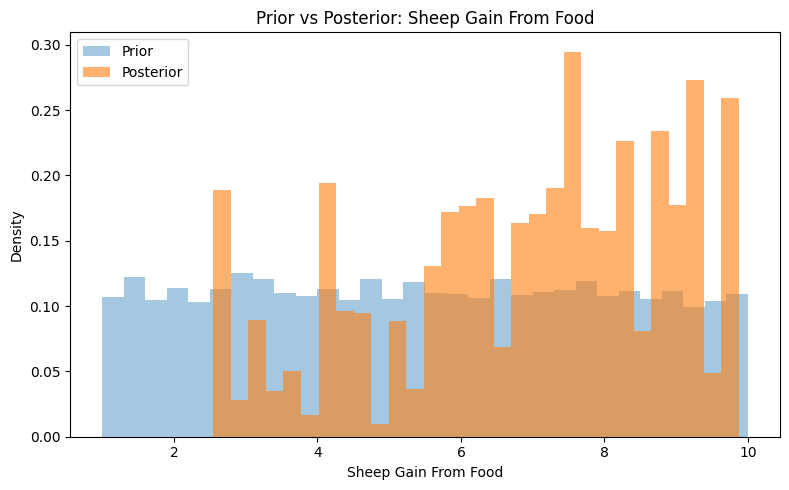

In [9]:
import numpy as np
import matplotlib.pyplot as plt


parameters = {
    "sheep_reproduce": "Sheep Reproduction",
    "wolf_reproduce": "Wolf Reproduction",
    "wolf_gain_from_food": "Wolf Gain From Food",
    "grass_regrowth_time": "Grass Regrowth Time",
    "sheep_gain_from_food": "Sheep Gain From Food",
}


# Posterior from final pyABC population
posterior, weights = history.get_distribution(
    m=0,
    t=history.max_t,
)


for parameter, label in parameters.items():

    # Draw samples from prior
    prior_samples = prior[parameter].rvs(
        size=10000
    )

    plt.figure(figsize=(8, 5))

    # Prior
    plt.hist(
        prior_samples,
        bins=30,
        density=True,
        alpha=0.4,
        label="Prior",
    )

    # Posterior
    plt.hist(
        posterior[parameter],
        weights=weights,
        bins=30,
        density=True,
        alpha=0.6,
        label="Posterior",
    )

    plt.xlabel(label)
    plt.ylabel("Density")
    plt.title(f"Prior vs Posterior: {label}")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import elfi

from caliagent.models import WolfSheep


# ------------------------------------------------------------
# Calibration settings
# ------------------------------------------------------------

N_STEPS = 100

TARGET_SHEEP = 120

INITIAL_SHEEP = 100
INITIAL_WOLVES = 50


# ------------------------------------------------------------
# Simulator
# ------------------------------------------------------------

def wolf_sheep_simulator(
    sheep_reproduce,
    wolf_reproduce,
    wolf_gain_from_food,
    grass_regrowth_time,
    sheep_gain_from_food,
    batch_size=1,
    random_state=None,
):
    """Run stochastic Wolf-Sheep simulations."""

    final_sheep = np.empty(batch_size)

    for i in range(batch_size):
        seed = None

        if random_state is not None:
            seed = random_state.randint(
                0,
                2**31 - 1,
            )

        model = WolfSheep(
            initial_sheep=INITIAL_SHEEP,
            initial_wolves=INITIAL_WOLVES,
            grass=True,
            sheep_reproduce=float(
                np.atleast_1d(sheep_reproduce)[i]
            ),
            wolf_reproduce=float(
                np.atleast_1d(wolf_reproduce)[i]
            ),
            wolf_gain_from_food=float(
                np.atleast_1d(wolf_gain_from_food)[i]
            ),
            grass_regrowth_time=int(
                round(
                    np.atleast_1d(
                        grass_regrowth_time
                    )[i]
                )
            ),
            sheep_gain_from_food=float(
                np.atleast_1d(sheep_gain_from_food)[i]
            ),
            seed=seed,
        )

        for _ in range(N_STEPS):
            model.step()

        final_sheep[i] = model.sheep_count

    return final_sheep


# ------------------------------------------------------------
# ELFI model
# ------------------------------------------------------------

m = elfi.ElfiModel()


# ------------------------------------------------------------
# Priors
# ------------------------------------------------------------

sheep_reproduce = elfi.Prior(
    "uniform",
    0.01,
    0.09,
    model=m,
    name="sheep_reproduce",
)

wolf_reproduce = elfi.Prior(
    "uniform",
    0.01,
    0.09,
    model=m,
    name="wolf_reproduce",
)

wolf_gain_from_food = elfi.Prior(
    "norm",
    6.5,
    1.0,
    model=m,
    name="wolf_gain_from_food",
)

grass_regrowth_time = elfi.Prior(
    "uniform",
    10.0,
    40.0,
    model=m,
    name="grass_regrowth_time",
)

sheep_gain_from_food = elfi.Prior(
    "uniform",
    1.0,
    9.0,
    model=m,
    name="sheep_gain_from_food",
)


# ------------------------------------------------------------
# Simulator node
# ------------------------------------------------------------

sim = elfi.Simulator(
    wolf_sheep_simulator,
    sheep_reproduce,
    wolf_reproduce,
    wolf_gain_from_food,
    grass_regrowth_time,
    sheep_gain_from_food,
    observed=np.array([TARGET_SHEEP]),
    name="sim",
)


# ------------------------------------------------------------
# Summary statistic
# ------------------------------------------------------------

summary = elfi.Summary(
    lambda x: x,
    sim,
    name="summary",
)


# ------------------------------------------------------------
# Discrepancy
# ------------------------------------------------------------

distance = elfi.Distance(
    "euclidean",
    summary,
    name="distance",
)


# ------------------------------------------------------------
# BOLFI
# ------------------------------------------------------------

bolfi = elfi.BOLFI(
    distance,
    batch_size=1,
    initial_evidence=50,
    update_interval=10,
    bounds={
        "sheep_reproduce": (0.01, 0.10),
        "wolf_reproduce": (0.01, 0.10),
        "wolf_gain_from_food": (2.0, 12.0),
        "grass_regrowth_time": (10.0, 50.0),
        "sheep_gain_from_food": (1.0, 10.0),
    },
    seed=1,
)


# ------------------------------------------------------------
# Learn discrepancy surface
# ------------------------------------------------------------

bolfi.fit(
    n_evidence=500,
)


# ------------------------------------------------------------
# Posterior
# ------------------------------------------------------------

posterior = bolfi.extract_posterior()


# ------------------------------------------------------------
# MCMC samples from approximate posterior
# ------------------------------------------------------------

result = bolfi.sample(
    n_samples=2000,
    warmup=500,
)


# ------------------------------------------------------------
# Plot wolf gain from food posterior
# ------------------------------------------------------------

samples = result.samples["wolf_gain_from_food"]

plt.figure(figsize=(8, 5))

plt.hist(
    samples,
    bins=30,
    density=True,
)

plt.xlabel("Wolf Gain From Food")
plt.ylabel("Posterior Density")
plt.title(
    "BOLFI Posterior: Wolf Gain From Food"
)

plt.tight_layout()
plt.show()

/mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/GPy/kern/src/symmetric.py:56: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if symmetry_type is 'odd':
/mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/GPy/kern/src/symmetric.py:58: SyntaxWarning: "is" with a literal. Did you mean "=="?
  elif symmetry_type is 'even':
 /mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/GPy/models/mrd.py:307: SyntaxWarning:"is not" with a literal. Did you mean "!="?
 /mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning:
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arvi

Progress [====----------------------------------------------] 9.8% Complete

 /mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/paramz/transformations.py:119: RuntimeWarning:overflow encountered in expm1
 /mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/paramz/transformations.py:121: RuntimeWarning:overflow encountered in expm1


Progress [=====---------------------------------------------] 10.0% Complete

 /mnt/c/Users/james/projects/calibrating-agent-based-models-workshop/.venv/lib/python3.11/site-packages/paramz/transformations.py:111: RuntimeWarning:overflow encountered in expm1


Progress [=====---------------------------------------------] 11.8% Complete

KeyboardInterrupt: 